In [1]:
from utils.utils import DataLoader, DopplerDataset, plot_learning_curves, plot_multiple_learning_curves, compare_multiple_learning_curves
from networks.model import Network_Class
import numpy as np
import matplotlib.pyplot as plt
import yaml
import os

# Load Data
base_path = "/Volumes/HIP_BACKUP/MEMOIRE/Code/MyDB2"
all = [f"NewExp{i}" for i in range(1, 51)]


In [ ]:
l_exp = [f"Regression/ResNet_Folds_debug{i}" for i in range(1, 4)]
folds = list(range(1, 2))
data_loader = DataLoader(base_path, exp_list=all)

for exp in l_exp :
    for fold in folds :
        print(f"🔔 Starting {exp} fold {fold}")
        stream = open(f"exp_list/{exp}.yaml", 'r')
        param  = yaml.safe_load(stream)
        param["TRAINING"]["DEVICE"] = 'mps'
        param["DATASET"]["FOLD_NUMBER"] = fold

        resultsPath = os.path.join("results", exp, f"fold{fold}")

        # Create the directory
        if not os.path.exists(resultsPath):
            os.makedirs(resultsPath)

        myNetwork = Network_Class(data_loader, param, resultsPath, sub_sample_factor=1)

        #myNetwork.visualize_data_augmentation()

        # Train the network
        train_losses, val_losses =  myNetwork.train()

        # Test the network
        #myNetwork.loadWeight()
        myNetwork.test(fold)


🔄 Chargement des données: 100%|██████████| 50/50 [00:00<00:00, 50.11exp/s]


🔔 Starting Regression/ResNet_Folds_debug1 fold 1

             DOPPLER DATASET INITIALIZATION SUMMARY
→ Active Antenna 2         : False
→ Active Phase             : False
→ Use previous frames      : False
→ Fold number              : 1
→ Total experiments        : 50
→ Dataset sizes (samples) :
   • Train set             : 40000
   • Validation set        : 5000
   • Test set              : 5000
→ Final selected dataset   : 50000 samples


                 NETWORK INITIALIZATION SUMMARY
→ Device                  : mps
→ Results path            : results/Regression/ResNet_Folds_debug1/fold1
→ Epochs                  : 20
→ Learning rate           : 0.0001
→ Batch size              : 16
→ Prediction type         : regression
→ Data augmentation       : False



🟢 Epoch 1/20: 100%|██████████| 2500/2500 [32:00<00:00,  1.12batch/s, loss=0.3433]

✅ Epoch 1/20 | Train Loss: 0.2356 | Val Loss: 0.1141
Model saved


🟢 Epoch 1/20: 100%|██████████| 2500/2500 [33:41<00:00,  1.24batch/s, loss=0.3433]


KeyboardInterrupt: 

In [3]:
all_train_losses = []
all_val_losses = []

exp = "Regression/ResNet_Folds_debug18"
resultsPath = os.path.join("results", exp)
folds = [1,2,3,4,5,6,7,8] #list(range(1, 9))

for fold in folds :
    train_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "train_losses.npy"))
    val_losses = np.load(os.path.join(resultsPath, f"fold{fold}", "val_losses.npy"))
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)

all_train_losses = np.array(all_train_losses)
all_val_losses = np.array(all_val_losses)

plot_multiple_learning_curves(all_train_losses, all_val_losses, resultsPath)


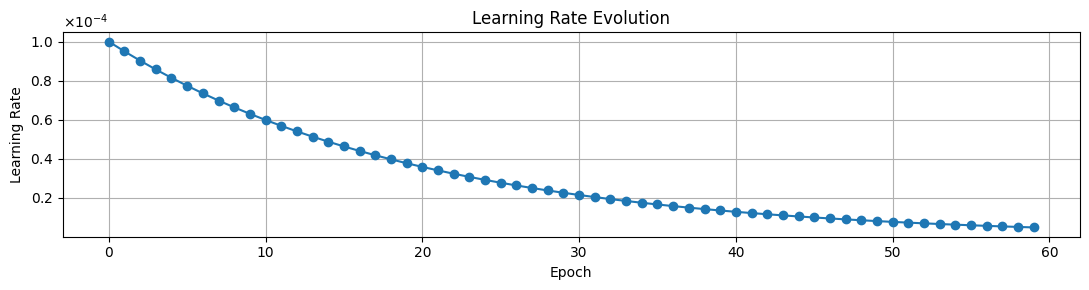

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker


# Paramètres donnés
initial_lr = 0.0001
gamma = 0.95
epochs = 60

# Calcul du LR pour chaque epoch
lr_values = [initial_lr * (gamma ** epoch) for epoch in range(epochs)]

# Tracé
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
# Activation de la notation scientifique pour l'axe y
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


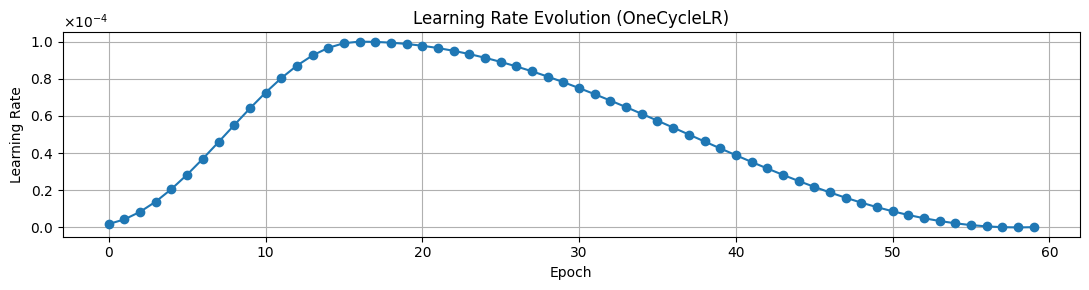

In [12]:
import torch
from torch.optim import Adam
from torch.optim.lr_scheduler import OneCycleLR
import torch.nn as nn

# Paramètres
epochs = 60
lr_start = 1e-6
max_lr = 1e-4
steps_per_epoch = 1  # pour visualisation simple : 1 update par epoch
total_steps = steps_per_epoch * epochs

# Dummy model
model = nn.Linear(10, 1)
optimizer = Adam(model.parameters(), lr=lr_start)

# Scheduler OneCycleLR
scheduler = OneCycleLR(
    optimizer,
    max_lr=max_lr,
    epochs=epochs,
    steps_per_epoch=steps_per_epoch,
    anneal_strategy="cos",
    div_factor=max_lr / lr_start  # pour respecter le lr de départ donné
)

# Simuler les updates
lr_values = []
for step in range(total_steps):
    scheduler.step()
    lr_values.append(optimizer.param_groups[0]['lr'])

# Tracer
plt.figure(figsize=(11, 3))
plt.plot(range(epochs), lr_values, marker='o')
plt.title("Learning Rate Evolution (OneCycleLR)")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
plt.tight_layout()
plt.show()


[0.2995527  0.2034432  0.17840496 0.16544195 0.15547341 0.1456364
 0.13683761 0.13366357 0.12869216 0.12597197 0.12244271 0.11731228
 0.11467031 0.11007938 0.109019   0.10633134 0.10223015 0.10068138
 0.09916529 0.09803971]
[ 0.77967274  0.5634866   0.21113216  0.34665207  0.19327704  0.11215937
  0.14738732  0.27737403  0.20671965  5.99245464 22.11078834 11.12726668
  0.19707327  0.52423333  2.31695428  0.21906875  0.60314391  9.55178111
  0.36232878  0.25760496]


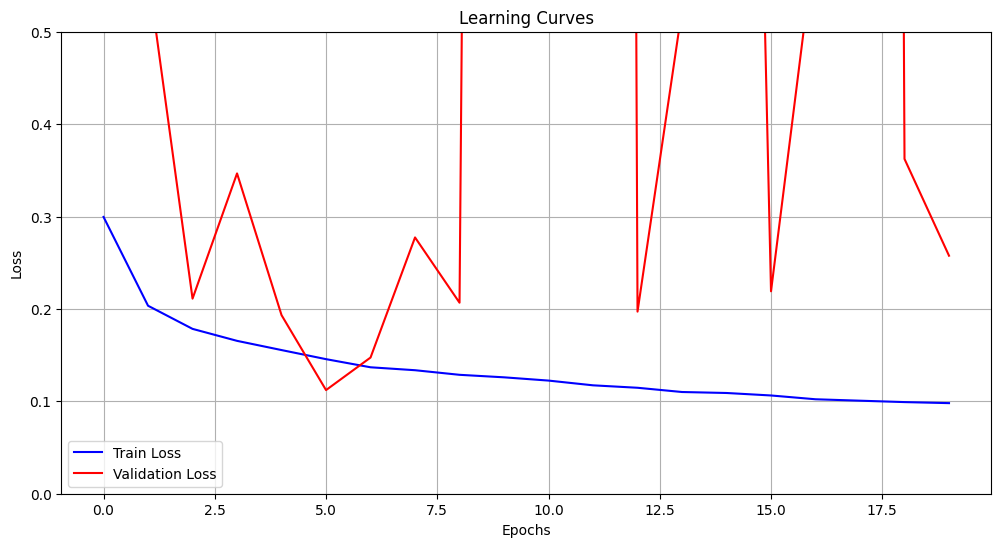

In [2]:
exp = "Regression/ResNet_Folds_debug4/fold5"
resultsPath = os.path.join("results", exp)

# Load learning curves
train_losses = np.load(os.path.join(resultsPath, "train_losses.npy"))
val_losses = np.load(os.path.join(resultsPath, "val_losses.npy"))
print(train_losses)
print(val_losses)

# Crop to only 20 epochs
train_losses = train_losses[:20]
val_losses = val_losses[:20]

# Crop y-axis to [0, 0.5]

plot_learning_curves(train_losses, val_losses, resultsPath, file_name="learning_curves_20epochs")

In [ ]:
exp1 = "Regression/ResNet_Folds_debug18/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

labels = ("Simple CNN - 1 path", "Simple CNN - 2 path", "Simple CNN - 2 path + ATROU")

# Stack train and val losses
train_all = [train1, train2, train3]
val_all = [val1, val2, val3]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [ ]:
exp1 = "Regression/ResNet_Folds_debug18/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

exp3 = "Regression/ResNet_Folds_debug26/fold5"
resultsPath3 = os.path.join("results", exp3)
train3 = np.load(os.path.join(resultsPath3, "train_losses.npy"))
val3 = np.load(os.path.join(resultsPath3, "val_losses.npy"))

labels = ("Simple CNN - 1 path", "Simple CNN - 2 path", "Simple CNN - 2 path + ATROU")
#labels = ("DA", "/", "DA + Previous Frames")

# Stack train and val losses
train_all = [train1, train2, train3]
val_all = [val1, val2, val3]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath3, title="Comparison of Learning Curves")

In [6]:
exp1 = "Regression/ResNet_Folds_debug21/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug22/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("2nd canal", "2nd canal + Atrou")

# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")

In [8]:
exp1 = "Regression/ResNet_Folds_debug26/fold5"
resultsPath1 = os.path.join("results", exp1)
train1 = np.load(os.path.join(resultsPath1, "train_losses.npy"))
val1 = np.load(os.path.join(resultsPath1, "val_losses.npy"))

exp2 = "Regression/ResNet_Folds_debug28/fold5"
resultsPath2 = os.path.join("results", exp2)
train2 = np.load(os.path.join(resultsPath2, "train_losses.npy"))
val2 = np.load(os.path.join(resultsPath2, "val_losses.npy"))


labels = ("-1", "-2")

# Stack train and val losses
train_all = [train1, train2]
val_all = [val1, val2]

compare_multiple_learning_curves(train_all, val_all, labels, resultsPath2, title="Comparison of Learning Curves")